# 03 Evaluation and Tuning

This notebook covers testing the trained model on unseen data, evaluating performance metrics, analyzing errors, and experimenting with hyperparameters.

## 1. Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

## 2. Load Preprocessed Data and Trained Model

In [2]:
# Load preprocessed data
data = np.load('../data/mnist_preprocessed.npz')
x_test = data['x_test']
y_test = data['y_test'] # One-hot encoded

# Load the trained model
model = load_model('../models/mnist_cnn_v1.h5')

print("Model and test data loaded successfully.")

Model and test data loaded successfully.


## 3. Test Set Evaluation
We evaluate the model's accuracy and loss on the test set.

In [3]:
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.0254
Test Accuracy: 0.9917


## 4. Performance Metrics (Detailed Analysis)

In [4]:
# Get predictions (probabilities)
y_pred_probs = model.predict(x_test)

# Convert probabilities to class labels (0-9)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true_classes, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.97      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



### Confusion Matrix Visualization

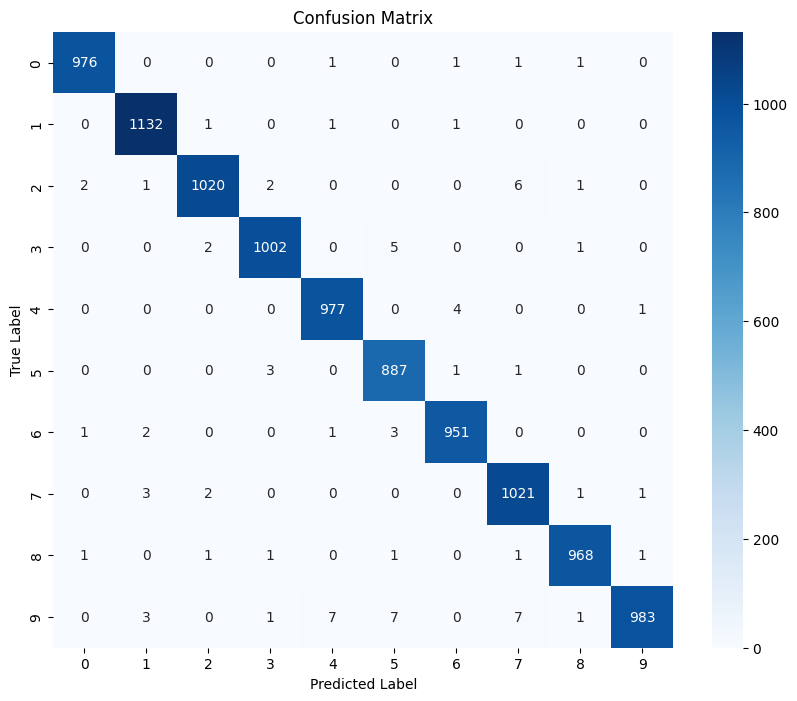

In [5]:
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## 5. Error Analysis (Misclassified Samples)

Total Misclassified Samples: 83


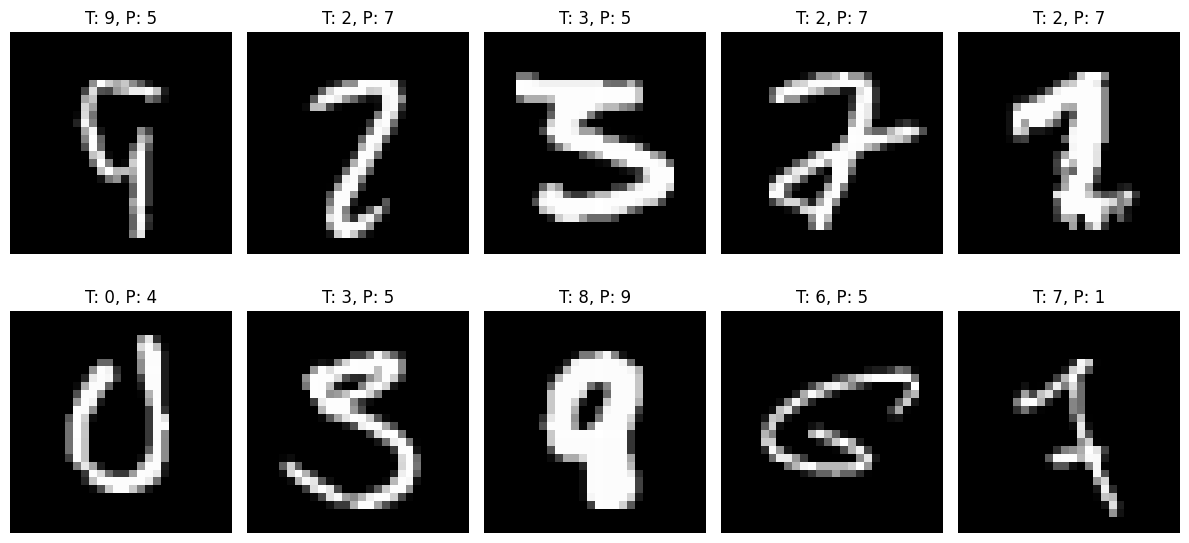

In [6]:
errors = np.where(y_pred_classes != y_true_classes)[0]
print(f"Total Misclassified Samples: {len(errors)}")

# Visualize first 10 mistakes
plt.figure(figsize=(12, 6))
for i, error_idx in enumerate(errors[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[error_idx].reshape(28, 28), cmap='gray')
    plt.title(f"T: {y_true_classes[error_idx]}, P: {y_pred_classes[error_idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning Strategy
Tuning parameters like **Learning Rate** or **Batch Size** to improve model performance.

In [7]:
def build_and_train_model(lr=0.001, batch_size=64, epochs=5):
    # Simple CNN Architecture for tuning
    model_tuning = load_model('../models/mnist_cnn_v1.h5')
    
    # Re-compile with custom learning rate
    model_tuning.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Load training data for tuning from .npz
    data_train = np.load('../data/mnist_preprocessed.npz')
    x_train, y_train = data_train['x_train'], data_train['y_train']
    
    # Filter down dataset for faster tuning experiments
    history = model_tuning.fit(x_train[:10000], y_train[:10000], 
                               epochs=epochs, 
                               batch_size=batch_size, 
                               validation_split=0.1, verbose=0)
    return history.history['val_accuracy'][-1]

# Quick Experiment with Learning Rate
for lr_val in [0.01, 0.001, 0.0001]:
    val_acc = build_and_train_model(lr=lr_val)
    print(f"Learning Rate: {lr_val} -> Final Val Accuracy: {val_acc:.4f}")

Learning Rate: 0.01 -> Final Val Accuracy: 0.9840


Learning Rate: 0.001 -> Final Val Accuracy: 0.9950
Learning Rate: 0.0001 -> Final Val Accuracy: 1.0000
